In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
from scipy.optimize import minimize

In [2]:
def convert_nh3_to_al_f(nh3_des_per_g, total_al_uc, si_al_ratio):
    """Convert NH3 desorption to Al_f per unit cell"""
    # Molecular weights
    MW_Al, MW_Si, MW_O, MW_H = 26.98, 28.09, 16.00, 1.008
    
    # Calculate T_Al and molecular weight
    T_Al = 36 / (si_al_ratio + 1)
    T_Si = 36 - T_Al
    MW_zeolite_per_uc = MW_Al * T_Al + MW_Si * T_Si + MW_O * 72 + MW_H * T_Al
    
    return nh3_des_per_g * MW_zeolite_per_uc

In [3]:
name = ['SK1-052 9.6 kPa-650C', 'TCM2-027 9.6 kPa-650C', 'TCM2-071 9.6 kPa-650C']
number = ['45', '22', '16']

exp = {}

for sname, anum in zip(name, number):
    df = pd.read_excel('250827 TCM Al content 9.6 kPa.xlsx', sheet_name=sname)
    df.columns = df.columns.str.strip()

    time_col, total_al_col, nh3_des_col, rate_col = 'Time / h', 'Total Al / uc', 'NH3 des. per g', 'Rate / mol ucˆ-1 hˆ-1'
    si_al_col = 'Si/Al'

    df_clean = df[[time_col, total_al_col, nh3_des_col, si_al_col, rate_col]].dropna()

    time_data      = pd.to_numeric(df_clean[time_col], errors='coerce').to_numpy()
    total_al_data  = pd.to_numeric(df_clean[total_al_col], errors='coerce').to_numpy()
    nh3_des_data   = pd.to_numeric(df_clean[nh3_des_col], errors='coerce').to_numpy()
    si_al_ratio    = pd.to_numeric(df_clean[si_al_col].iloc[0], errors='coerce')
    rate_data      = pd.to_numeric(df_clean[rate_col], errors='coerce').to_numpy()

    al_f_data = np.array([
        convert_nh3_to_al_f(nh3, total_al_data[i], si_al_ratio)
        for i, nh3 in enumerate(nh3_des_data)
    ])

    exp[anum] = {
        'time':  time_data,
        'Al_f':  al_f_data,
        'Al_tot': total_al_data[0],
        'rate':  rate_data,
    }

exp

{'45': {'time': array([ 0.,  2.,  4.,  8., 16., 32., 64.]),
  'Al_f': array([0.57793934, 0.44606673, 0.35159301, 0.30447279, 0.19025257,
         0.1190359 , 0.0683903 ]),
  'Al_tot': np.float64(0.7539061007838296),
  'rate': array([0.08068456, 0.0485394 , 0.03237917, 0.01733956, 0.00734544,
         0.00254685, 0.00076691])},
 '22': {'time': array([ 0. ,  1. ,  1.5,  2. ,  4. ,  6. ,  8. , 12. , 16. , 22. ]),
  'Al_f': array([1.06360903, 0.764354  , 0.66100065, 0.62858508, 0.47474017,
         0.37571418, 0.30535558, 0.22266848, 0.18058097, 0.1481312 ]),
  'Al_tot': np.float64(1.4662980027207297),
  'rate': array([0.4178794 , 0.20170608, 0.15305055, 0.12053673, 0.05845077,
         0.03500953, 0.02353397, 0.0129365 , 0.00827638, 0.00496473])},
 '16': {'time': array([ 0.  ,  0.5 ,  1.  ,  1.5 ,  2.  ,  2.5 ,  3.  ,  3.5 ,  6.5 ,
         10.75]),
  'Al_f': array([1.69098957, 0.8527369 , 0.56334472, 0.4222341 , 0.35084747,
         0.28044497, 0.29166648, 0.25271929, 0.18129413, 0.15601

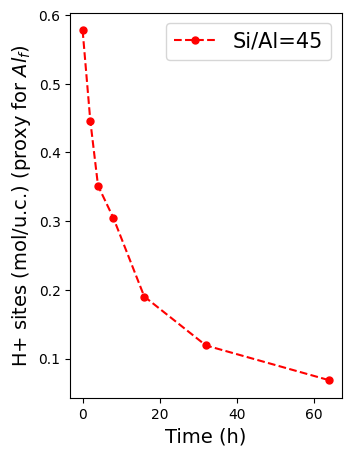

In [15]:
colors = {'45': 'r', '22': 'b', '16': 'g'}
plt.figure(figsize=(3.5,5))
plt.plot(exp['45']['time'],exp['45']['Al_f'],'.--', color = colors['45'], markersize=10,label='Si/Al=45')
# plt.plot(exp['22']['time'],exp['22']['Al_f'],'.--', color = colors['22'], markersize=10,label='Si/Al=22')
# plt.plot(exp['16']['time'],exp['16']['Al_f'],'.--', color = colors['16'], markersize=10,label='Si/Al=16')
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel(r'H+ sites (mol/u.c.) (proxy for $Al_f$)', fontsize=14)
plt.legend(fontsize=15)
plt.savefig('my_figure.png', bbox_inches='tight', dpi=100)

# Linear regression with first-order model
### $$ ln([Al_f])=ln([Al_f]_0)-k_{app}*t $$
### Plot $ln([Al_f])$ vs. $t$

k_app = 0.0315, R^2 = 0.9104
k_app = 0.0861, R^2 = 0.9155
k_app = 0.1778, R^2 = 0.6372


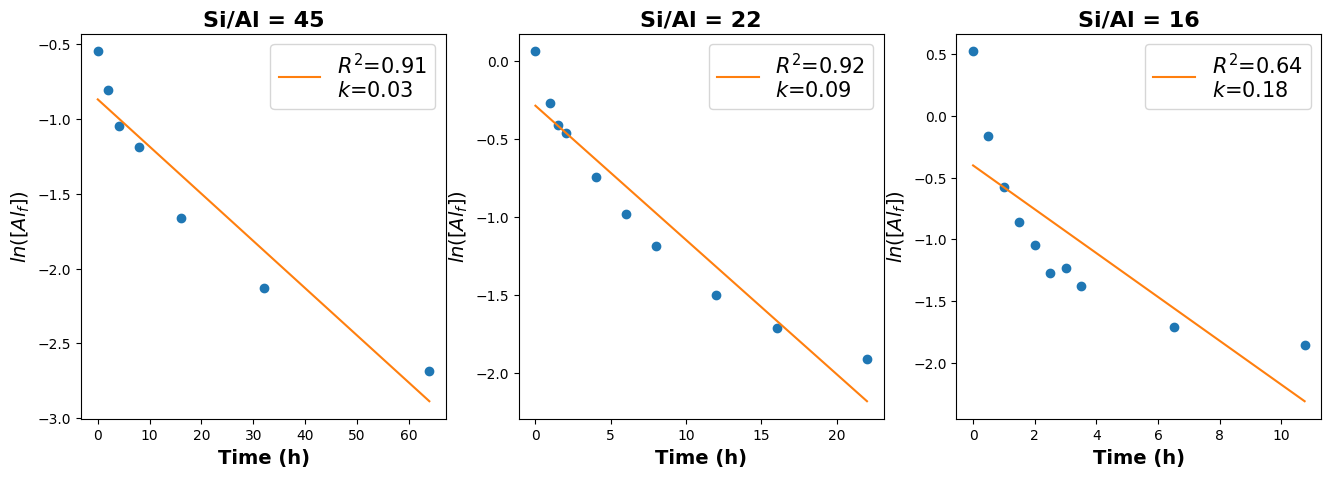

In [5]:
from scipy.stats import linregress

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, key in enumerate(['45', '22', '16']):
    ax = axes[idx]
    time = exp[key]['time']
    lnAl = np.log(exp[key]['Al_f'])
    ax.plot(time,lnAl,'o')
    a, b, r,_,_=linregress(time, lnAl)
    def cont_func(a,b,t):
        return a*t+b
    t = np.linspace(0,time[-1],100)
    ax.plot(t, cont_func(a,b,t),label=f'$R^2$={r**2:.2f}\n$k$={-a:.2f}')
    ax.set_xlabel('Time (h)', fontsize=14, fontweight='bold')
    ax.set_ylabel(r'$ln([Al_f])$', fontsize=14, fontweight='bold')
    ax.set_title(f'Si/Al = {key}', fontsize=16, fontweight='bold')
    ax.legend(fontsize=15)
    print(f'k_app = {-a:.4f}, R^2 = {r**2:.4f}')

# Linear regression with second-order model
### $$\frac{1}{[Al_f]}=\frac{1}{[Al_f]_0}+k_{app}*t$$
### Plot $\frac{1}{[Al_f]}$ vs. $t$

k_app = 0.2005, R^2 = 0.9989
k_app = 0.2691, R^2 = 0.9959
k_app = 0.5314, R^2 = 0.8905


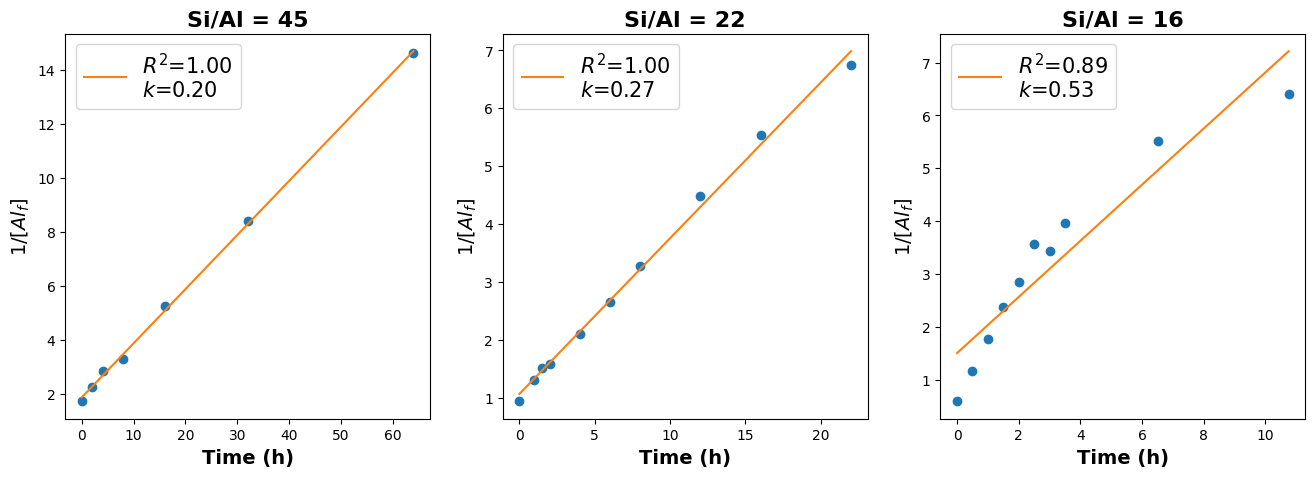

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, key in enumerate(['45', '22', '16']):
    ax = axes[idx]
    time = exp[key]['time']
    invAlf = 1/exp[key]['Al_f']
    ax.plot(time,invAlf,'o')
    a, b, r,_,_=linregress(time, invAlf)
    def cont_func(a,b,t):
        return a*t+b
    t = np.linspace(0,time[-1],100)
    ax.plot(t, cont_func(a,b,t),label=f'$R^2$={r**2:.2f}\n$k$={a:.2f}')
    ax.set_xlabel('Time (h)', fontsize=14, fontweight='bold')
    ax.set_ylabel(r'$1/[Al_f]$', fontsize=14, fontweight='bold')
    ax.set_title(f'Si/Al = {key}', fontsize=16, fontweight='bold')
    ax.legend(fontsize=15)
    print(f'k_app = {a:.4f}, R^2 = {r**2:.4f}')

# Linear regression with third-order model
### $$\frac{1}{2[Al_f]^2}=k_{app}*t-\frac{1}{2[Al_f]_0^2}$$
### Plot $\frac{1}{2[Al_f]^2}$ vs. $t$

k_app = 1.6310, R^2 = 0.9632
k_app = 1.0148, R^2 = 0.9750
k_app = 2.0112, R^2 = 0.9796


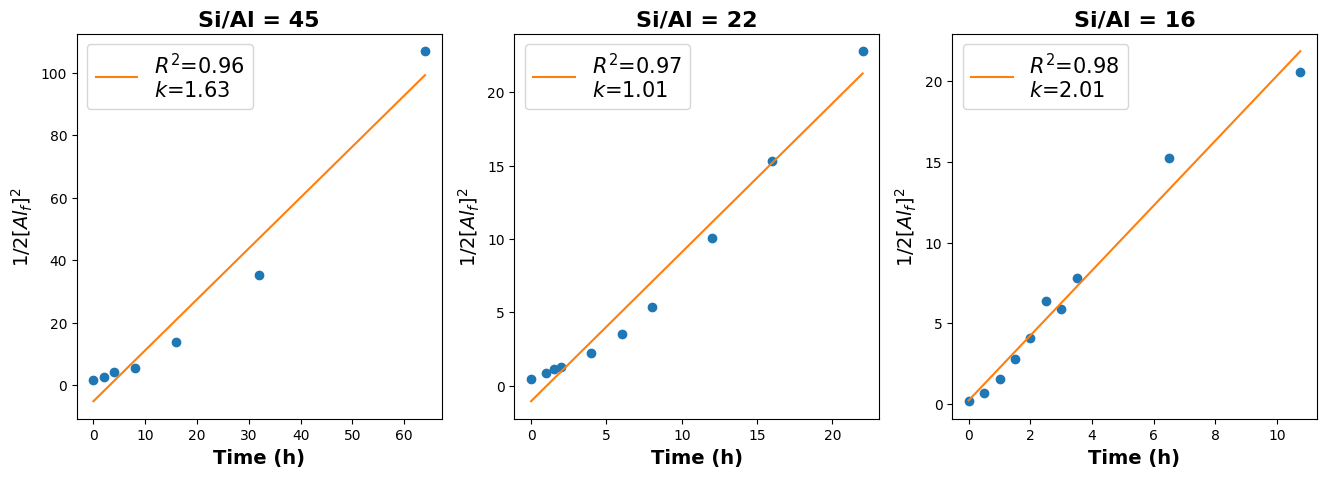

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, key in enumerate(['45', '22', '16']):
    ax = axes[idx]
    time = exp[key]['time']
    invAlf2 = 1/(2*exp[key]['Al_f']**2)
    ax.plot(time,invAlf2,'o')
    a, b, r,_,_=linregress(time, invAlf2)
    def cont_func(a,b,t):
        return a*t+b
    t = np.linspace(0,time[-1],100)
    ax.plot(t, cont_func(a,b,t),label=f'$R^2$={r**2:.2f}\n$k$={a:.2f}')
    ax.set_xlabel('Time (h)', fontsize=14, fontweight='bold')
    ax.set_ylabel(r'$1/2[Al_f]^2$', fontsize=14, fontweight='bold')
    ax.set_title(f'Si/Al = {key}', fontsize=16, fontweight='bold')
    ax.legend(fontsize=15)
    print(f'k_app = {a:.4f}, R^2 = {r**2:.4f}')

# For best fits

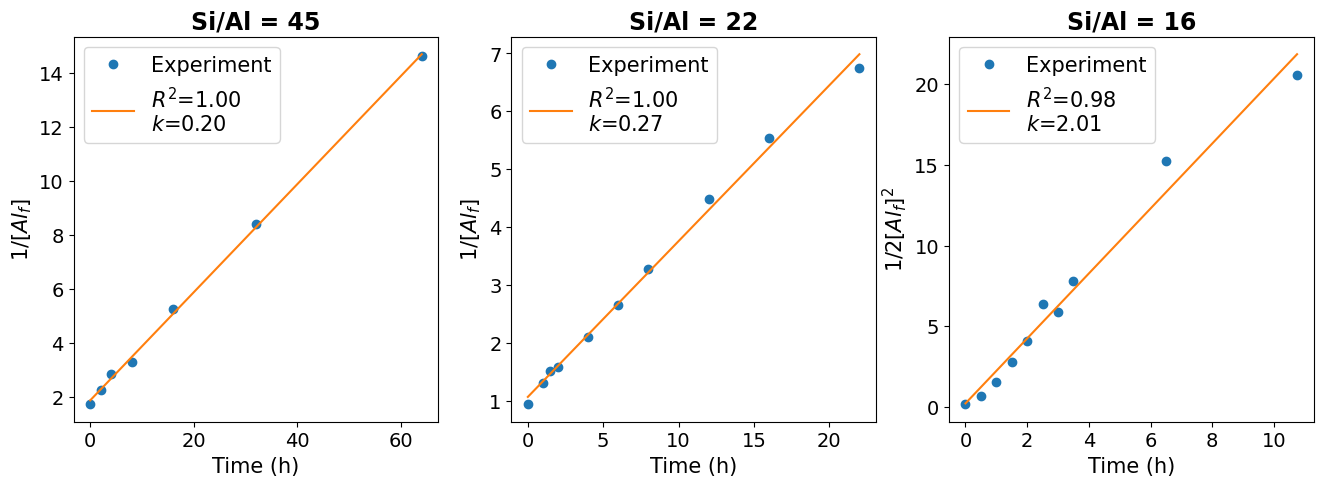

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, key in enumerate(['45', '22', '16']):
    if key in ['45','22']:
        ax = axes[idx]
        time = exp[key]['time']
        invAlf = 1/exp[key]['Al_f']
        ax.plot(time,invAlf,'o',label='Experiment')
        a, b, r,_,_=linregress(time, invAlf)
        def cont_func(a,b,t):
            return a*t+b
        t = np.linspace(0,time[-1],100)
        ax.plot(t, cont_func(a,b,t),label=f'$R^2$={r**2:.2f}\n$k$={a:.2f}')
        ax.set_xlabel('Time (h)', fontsize=15)
        ax.set_ylabel(r'$1/[Al_f]$', fontsize=15)
        ax.set_title(f'Si/Al = {key}', fontsize=17, fontweight='bold')
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.legend(fontsize=15)
    elif key == '16':
        ax = axes[idx]
        time = exp[key]['time']
        invAlf2 = 1/(2*exp[key]['Al_f']**2)
        ax.plot(time,invAlf2,'o',label='Experiment')
        a, b, r,_,_=linregress(time, invAlf2)
        def cont_func(a,b,t):
            return a*t+b
        t = np.linspace(0,time[-1],100)
        ax.plot(t, cont_func(a,b,t),label=f'$R^2$={r**2:.2f}\n$k$={a:.2f}')
        ax.set_xlabel('Time (h)', fontsize=15)
        ax.set_ylabel(r'$1/2[Al_f]^2$', fontsize=15)
        ax.set_title(f'Si/Al = {key}', fontsize=17, fontweight='bold')
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.legend(fontsize=15)

# Determine apparent reaction order

### $$ r =-\frac{d[Al_f]}{dt}= k_{app}[Al_f]^n$$
### $$ -\frac{[Al_f]^{1-n}}{k_{app}(1-n)} = t $$


Dataset: 45
Apparent rate constant (k_app): 0.284394 ± 0.066544
Reaction order (n):              2.2224 ± 0.2021
Initial [Al_f]:                  0.574084 ± 0.015611
R²:                              0.994688

Dataset: 22
Apparent rate constant (k_app): 0.357916 ± 0.021084
Reaction order (n):              2.2778 ± 0.0928
Initial [Al_f]:                  1.056808 ± 0.015971
R²:                              0.997607

Dataset: 16
Apparent rate constant (k_app): 1.210692 ± 0.063485
Reaction order (n):              2.2956 ± 0.1115
Initial [Al_f]:                  1.694365 ± 0.028819
R²:                              0.997007
7.757575757575758
2.888888888888889
0.43434343434343436


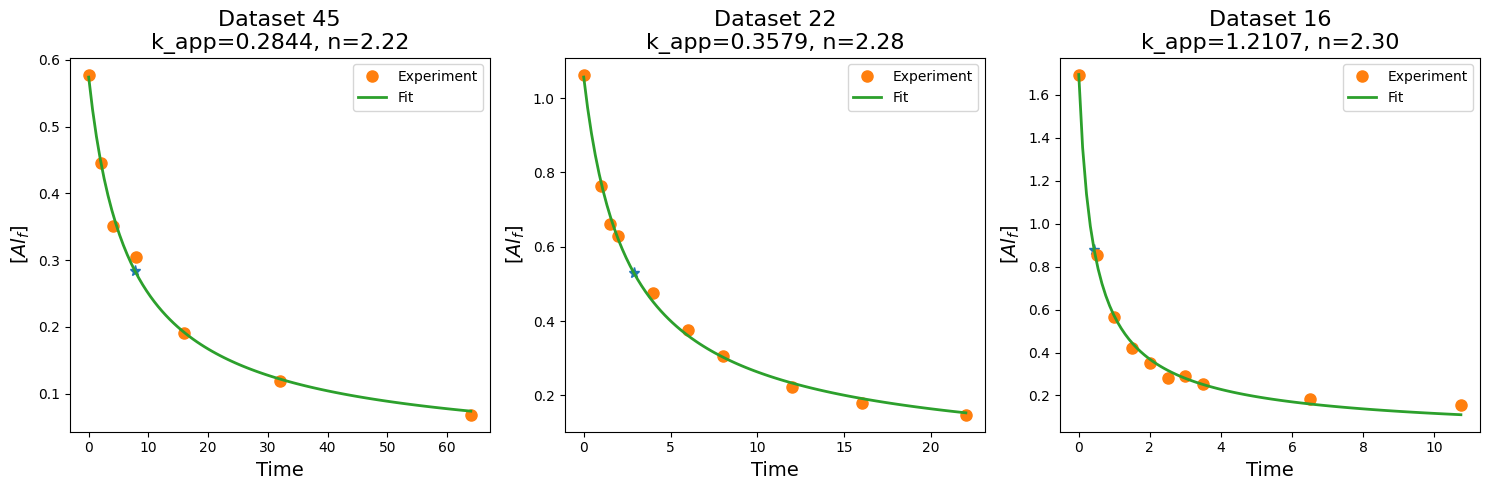

In [20]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

data = {
    '45': {'time': np.array([0., 2., 4., 8., 16., 32., 64.]),
           'Al_f': np.array([0.57793934, 0.44606673, 0.35159301, 0.30447279, 
                            0.19025257, 0.1190359, 0.0683903]),
           'Al_tot': 0.7539061007838296},
    '22': {'time': np.array([0., 1., 1.5, 2., 4., 6., 8., 12., 16., 22.]),
           'Al_f': np.array([1.06360903, 0.764354, 0.66100065, 0.62858508, 
                            0.47474017, 0.37571418, 0.30535558, 0.22266848, 
                            0.18058097, 0.1481312]),
           'Al_tot': 1.4662980027207297},
    '16': {'time': np.array([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 6.5, 10.75]),
           'Al_f': np.array([1.69098957, 0.8527369, 0.56334472, 0.4222341, 
                            0.35084747, 0.28044497, 0.29166648, 0.25271929, 
                            0.18129413, 0.1560142]),
           'Al_tot': 2.0613851873073203}
}

def integrated_rate_law(t, k_app, n, Al_f0):
    """
    Integrated rate law for -d[Al_f]/dt = k_app * [Al_f]^n
    
    For n ≠ 1: [Al_f]^(1-n) = [Al_f0]^(1-n) - k_app*(1-n)*t
    For n = 1: ln([Al_f]) = ln([Al_f0]) - k_app*t
    
    We use a smooth approximation near n=1 to avoid singularity
    """
    epsilon = 1e-6  # threshold for considering n ≈ 1
    
    if abs(n - 1) < epsilon:
        # First-order kinetics: [Al_f] = [Al_f0] * exp(-k_app*t)
        return Al_f0 * np.exp(-k_app * t)
    else:
        # General order kinetics
        term = Al_f0**(1-n) - k_app * (1-n) * t
        # Ensure we don't get negative values under the power
        term = np.maximum(term, 1e-10)
        return term**(1/(1-n))

# Fit each dataset
results = {}

for key, dataset in data.items():
    time = dataset['time']
    Al_f = dataset['Al_f']
    Al_f0 = Al_f[0]  # Initial concentration
    
    # Initial guesses: k_app ~ 0.01, n ~ 1 (first order)
    # We'll try multiple initial guesses to avoid local minima
    initial_guesses = [
        (0.01, 1.0, Al_f0),
        (0.1, 0.5, Al_f0),
        (0.05, 1.5, Al_f0),
        (0.001, 2.0, Al_f0)
    ]
    
    best_fit = None
    best_error = np.inf
    
    for guess in initial_guesses:
        try:
            # Fit the data
            popt, pcov = curve_fit(
                integrated_rate_law, 
                time, 
                Al_f, 
                p0=guess,
                bounds=([0, 0, Al_f0*0.9], [np.inf, 5, Al_f0*1.1]),
                maxfev=10000
            )
            
            # Calculate residual error
            predicted = integrated_rate_law(time, *popt)
            error = np.sum((Al_f - predicted)**2)
            
            if error < best_error:
                best_error = error
                best_fit = (popt, pcov)
        except:
            continue
    
    if best_fit is not None:
        popt, pcov = best_fit
        k_app, n, Al_f0_fit = popt
        
        # Calculate standard errors
        perr = np.sqrt(np.diag(pcov))
        
        # Calculate R²
        predicted = integrated_rate_law(time, *popt)
        ss_res = np.sum((Al_f - predicted)**2)
        ss_tot = np.sum((Al_f - np.mean(Al_f))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        results[key] = {
            'k_app': k_app,
            'n': n,
            'Al_f0': Al_f0_fit,
            'k_app_err': perr[0],
            'n_err': perr[1],
            'R2': r_squared
        }
        
        print(f"\n{'='*60}")
        print(f"Dataset: {key}")
        print(f"{'='*60}")
        print(f"Apparent rate constant (k_app): {k_app:.6f} ± {perr[0]:.6f}")
        print(f"Reaction order (n):              {n:.4f} ± {perr[1]:.4f}")
        print(f"Initial [Al_f]:                  {Al_f0_fit:.6f} ± {perr[2]:.6f}")
        print(f"R²:                              {r_squared:.6f}")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (key, dataset) in enumerate(data.items()):
    time = dataset['time']
    Al_f = dataset['Al_f']
    
    if key in results:
        k_app = results[key]['k_app']
        n = results[key]['n']
        Al_f0 = results[key]['Al_f0']
        
        # Generate smooth curve
        t_smooth = np.linspace(0, time[-1], 100)
        Al_f_fit = integrated_rate_law(t_smooth, k_app, n, Al_f0)
        idd = np.abs(Al_f_fit-Al_f_fit[0]/2).argmin()
        print(t_smooth[idd])
        axes[idx].plot(t_smooth[idd],Al_f_fit[idd],'*', markersize=8)
        axes[idx].plot(time, Al_f, 'o', label='Experiment', markersize=8)
        axes[idx].plot(t_smooth, Al_f_fit, '-', label='Fit', linewidth=2)
        axes[idx].set_xlabel('Time', fontsize=14)
        axes[idx].set_ylabel(r'$[Al_f]$', fontsize=14)
        axes[idx].set_title(f'Dataset {key}\nk_app={k_app:.4f}, n={n:.2f}', fontsize=16)
        # axes[idx].set_ylim(0,data['16']['Al_tot']+0.1)
        # axes[idx].set_xlim(0,data['45']['time'][-1]+5)
        axes[idx].legend()
plt.tight_layout()
plt.show()

In [16]:
Al_f_fit
idx = np.abs(Al_f_fit-Al_f_fit[0]/2).argmin()
Al_f_fit[idx]

np.float64(0.2835517738406088)

In [17]:
t_smooth[idx]

np.float64(7.757575757575758)

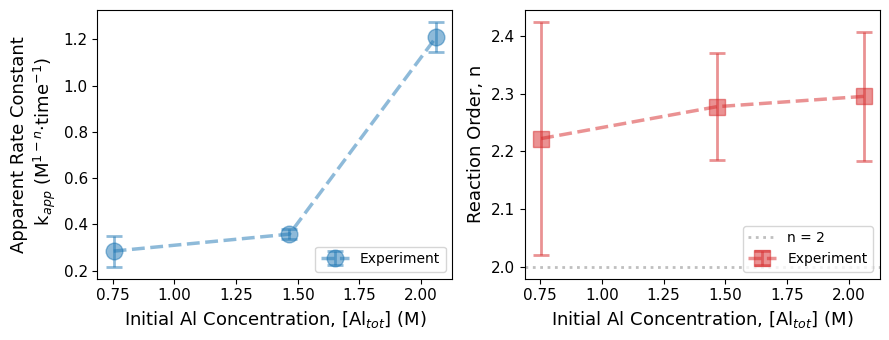

In [22]:
# Extract results and organize data
datasets = ['45', '22', '16']
Al_tot_values = [data[key]['Al_tot'] for key in datasets]
k_app_values = [results[key]['k_app'] for key in datasets]
k_app_errors = [results[key]['k_app_err'] for key in datasets]
n_values = [results[key]['n'] for key in datasets]
n_errors = [results[key]['n_err'] for key in datasets]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# Plot 1: k_app vs [Al_tot]
ax1.errorbar(Al_tot_values, k_app_values, yerr=k_app_errors, 
             fmt='o--', color='tab:blue', alpha=0.5, markersize=12, linewidth=2.5, 
             capsize=6, capthick=2, elinewidth=2, label='Experiment')
ax1.set_xlabel('Initial Al Concentration, [Al$_{tot}$] (M)', fontsize=13)
ax1.set_ylabel('Apparent Rate Constant\n k$_{app}$ (M$^{1-n}$·time$^{-1}$)', fontsize=13)
ax1.tick_params(axis='both', labelsize=11)
ax1.legend(fontsize=10, loc='lower right')

# Plot 2: n vs [Al_tot]
ax2.errorbar(Al_tot_values, n_values, yerr=n_errors, 
             fmt='s--', color='tab:red', alpha=0.5, markersize=12, linewidth=2.5, 
             capsize=6, capthick=2, elinewidth=2,label='Experiment')
ax2.set_xlabel('Initial Al Concentration, [Al$_{tot}$] (M)', fontsize=13)
ax2.set_ylabel('Reaction Order, n', fontsize=13)
ax2.tick_params(axis='both', labelsize=11)

# Add reference line at n=2
ax2.axhline(y=2.0, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='n = 2')
ax2.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

In [18]:
Al_tot_values=[0.7539061007838296, 1.4662980027207297, 2.0613851873073203]
exp_k_app_values=[np.float64(0.2843937683960249),
 np.float64(0.3579157123876951),
 np.float64(1.2106917445671188)]
exp_k_app_errors=[np.float64(0.06654404717395045),
 np.float64(0.021083520945710404),
 np.float64(0.06348515664058021)]
exp_n_values=[np.float64(2.2223652132086746),
 np.float64(2.2777734335510957),
 np.float64(2.295635065360914)]
exp_n_errors=[np.float64(0.20214631504815642),
 np.float64(0.09276706826033954),
 np.float64(0.11153885812494263)]